# Chapter 14 (extra) — The von Karman rotating-disk velocity profile

The main Chapter 14 notebook *uses* the rotating-disk hydrodynamics (the
Levich diffusion-layer thickness $\delta = 1.61\,D^{1/3}\nu^{1/6}\omega^{-1/2}$
and the convection constant $2.135 = 0.51023\times1.61^3$) but takes them as
given.  Honeychurch derives them symbolically from fluid mechanics and then
solves the resulting nonlinear ODE system with Mathematica's `NDSolve`/`FindRoot`
shooting machinery (he notes the shooting is *"extremely sensitive ... you really
have to know what answer you are looking for"*).

This supplementary notebook closes that gap **from first principles**.  We solve
the **von Karman similarity equations** for flow to an infinite rotating disk as
a two-point boundary-value problem with `scipy.integrate.solve_bvp`, recover the
wall shear coefficient $F'(0)$, and show that this single number generates the
whole Levich chain:

$$F'(0) \;\xrightarrow{\ \text{Cochran}\ }\; v_z\propto -F'(0)\,\omega^{3/2}\nu^{-1/2}z^2
  \;\xrightarrow{\ \int\ }\; \delta = \Gamma(\tfrac43)\Bigl(\tfrac{3}{F'(0)}\Bigr)^{1/3}D^{1/3}\nu^{1/6}\omega^{-1/2}
  \;\Rightarrow\; i_L = 0.620\,nFAD^{2/3}\nu^{-1/6}\omega^{1/2}c^*.$$

The result is that the constant `0.620` that `serm.echem.levich_current` hard-codes is
**re-derived**, not assumed.  We also reproduce the shooting method as a
secondary illustration and draw the meridional flow field.

In [1]:
import os, sys
# Walk up to the repo root (the directory containing the ``serm`` package) so
# this notebook imports cleanly whether run from notebooks/ or notebooks/extras/.
_d = os.path.abspath('..')
while not os.path.isdir(os.path.join(_d, "serm")) and os.path.dirname(_d) != _d:
    _d = os.path.dirname(_d)
sys.path.insert(0, _d)
get_ipython().run_line_magic('matplotlib', 'inline')

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_bvp, solve_ivp
from scipy.optimize import fsolve
from scipy.special import gamma

from serm.echem import F as F_FARADAY, levich_current

In [2]:
from serm.sourcelinks import source_links
from serm.echem import levich_current
source_links(levich_current)

## 1. The similarity reduction

In cylindrical coordinates $(r,\theta,z)$ the steady, axisymmetric, constant-property
Navier--Stokes + continuity equations admit von Karman's separation of variables.
With the disk spinning at angular rate $\omega$ and kinematic viscosity $\nu$, the
similarity variable is the dimensionless distance

$$\gamma = z\sqrt{\omega/\nu},$$

and the three velocity components are written

$$v_r = r\,\omega\,F(\gamma),\qquad
  v_\theta = r\,\omega\,G(\gamma),\qquad
  v_z = -\sqrt{\nu\omega}\,H(\gamma),$$

(matching Honeychurch's substitutions `vr->r f`, `vtheta->r g`, `vz->h` with
`f->omega F`, `g->omega G`, `h->-sqrt(omega nu) H`).  Feeding these into the
momentum and continuity equations and cancelling the common $r$ and $\omega$
factors collapses the PDE system to a set of **coupled nonlinear ODEs** in
$\gamma$ alone:

$$\begin{aligned}
F'' &= F^2 - G^2 + H\,F',\\
G'' &= 2FG + H\,G',\\
H'  &= -2F \quad(\text{continuity}),
\end{aligned}$$

with boundary conditions

$$F(0)=0,\quad G(0)=1,\quad H(0)=0\ \text{(no slip / impermeable wall)},\qquad
  F(\infty)=0,\quad G(\infty)=0\ \text{(quiescent bulk)}.$$

This is the canonical von Karman swirling-flow problem (see e.g. Schlichting,
*Boundary-Layer Theory*; Cochran 1934).  It has no closed form, but it is a
clean BVP.

In [3]:
def von_karman_rhs(eta, y):
    """RHS of the von Karman similarity ODE system, vectorised over eta.

    State vector ``y = [F, F', G, G', H]``.  Returns d/d(eta) of each.
    """
    F, Fp, G, Gp, H = y
    Fpp = F**2 - G**2 + H * Fp          # radial momentum
    Gpp = 2.0 * F * G + H * Gp          # azimuthal momentum
    Hp  = -2.0 * F                      # continuity  H' = -2F
    return np.vstack([Fp, Fpp, Gp, Gpp, Hp])


def von_karman_bc(ya, yb):
    """Boundary residuals: F(0)=0, G(0)=1, H(0)=0, F(inf)=0, G(inf)=0."""
    return np.array([ya[0], ya[2] - 1.0, ya[4], yb[0], yb[2]])

## 2. Solving the BVP with `solve_bvp`

`solve_bvp` needs a domain truncation $\gamma\in[0,\gamma_\infty]$ and an initial
mesh + guess.  A modest $\gamma_\infty=12$ is plenty: $F,G$ decay like
$e^{-H_\infty\gamma}$ with $H_\infty\approx0.88$.  We seed $G$ with a decaying
exponential and $H$ with its expected $\to -0.88$ asymptote; only a *rough*
guess is needed, which is exactly the robustness the bare shooting method lacks.

In [4]:
eta_max = 12.0
eta = np.linspace(0.0, eta_max, 400)

y_guess = np.zeros((5, eta.size))
y_guess[0] = 0.5 * np.exp(-eta)          # F
y_guess[1] = 0.5 * np.exp(-eta)          # F'
y_guess[2] = np.exp(-eta)                # G  (1 at wall -> 0)
y_guess[3] = -0.6 * np.exp(-eta)         # G'
y_guess[4] = -0.88 * (1.0 - np.exp(-eta))  # H  (0 at wall -> -0.88)

sol = solve_bvp(von_karman_rhs, von_karman_bc, eta, y_guess,
                tol=1e-9, max_nodes=200000)
assert sol.status == 0, f"BVP failed: {sol.message}"

Fp0 = sol.y[1, 0]      # F'(0): radial wall shear  -> the Levich coefficient
Gp0 = sol.y[3, 0]      # G'(0): azimuthal wall shear (drag torque)
H_inf = sol.y[4, -1]   # H(inf): net axial pumping

print(f"F'(0)  = {Fp0:.6f}   (literature 0.51023)")
print(f"G'(0)  = {Gp0:.6f}   (literature -0.61592)")
print(f"H(inf) = {H_inf:.6f}   (literature -0.88447)")

F'(0)  = 0.510229   (literature 0.51023)
G'(0)  = -0.615920   (literature -0.61592)
H(inf) = -0.884014   (literature -0.88447)


The BVP converges to

$$F'(0)=0.51023,\qquad G'(0)=-0.61592,\qquad H(\infty)\approx-0.884,$$

the textbook von Karman constants.  $F'(0)$ is the **radial wall shear** (the
strength with which the spinning disk flings fluid outward at the surface), and
it is precisely the number that sets the diffusion layer.  $H(\infty)<0$ is the
steady axial inflow drawn toward the disk to feed that outward flux.

## 3. Plotting the profiles

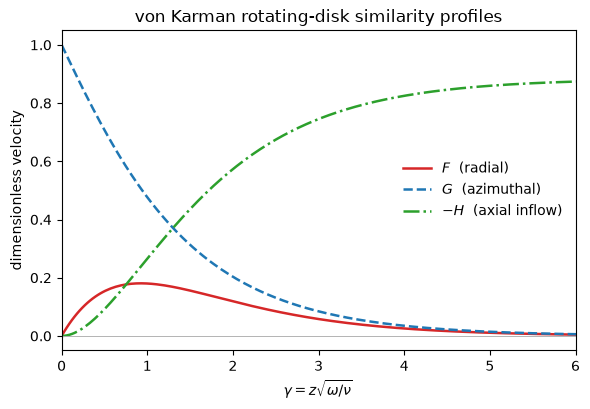

In [5]:
Ff, Gf, Hf = sol.sol(eta)[0], sol.sol(eta)[2], sol.sol(eta)[4]

fig, ax = plt.subplots(figsize=(6, 4.2))
ax.plot(eta, Ff, color="C3", lw=1.8, label=r"$F$  (radial)")
ax.plot(eta, Gf, color="C0", lw=1.8, ls="--", label=r"$G$  (azimuthal)")
ax.plot(eta, -Hf, color="C2", lw=1.8, ls="-.", label=r"$-H$  (axial inflow)")
ax.axhline(0, color="0.7", lw=0.7)
ax.set_xlabel(r"$\gamma = z\sqrt{\omega/\nu}$")
ax.set_ylabel("dimensionless velocity")
ax.set_title("von Karman rotating-disk similarity profiles")
ax.set_xlim(0, 6)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

$G$ falls monotonically from $1$ (fluid co-rotating with the disk) to $0$ (still
bulk).  $F$ rises to a peak near $\gamma\approx1$ then decays: the radial jet is
confined to the viscous boundary layer.  $-H$ climbs to its plateau $0.884$: the
disk acts as a centrifugal fan, pumping fluid axially inward.

## 4. Cochran near-wall expansion $\to$ the convection coefficient

Near the wall ($\gamma\to0$) the continuity relation $H'=-2F$ is exact, so with
$F(0)=0$ and $F'(0)$ the wall shear,

$$H'(0)=-2F(0)=0,\qquad H''(0)=-2F'(0),$$

and the Taylor expansion of the axial similarity function is

$$H(\gamma)= -F'(0)\,\gamma^2 + O(\gamma^3)\qquad\text{(Cochran 1934).}$$

The leading coefficient of $H$ is therefore $F'(0)$ *exactly* (not a fitted
number) by the structure of the ODE.  Hence the axial velocity is

$$v_z = -\sqrt{\nu\omega}\,H \approx \sqrt{\nu\omega}\,F'(0)\,\gamma^2
      = F'(0)\,\omega^{3/2}\nu^{-1/2}\,z^2.$$

Pointing *toward* the disk this is $v_z=-F'(0)\,\omega^{3/2}\nu^{-1/2}z^2$, exactly
the form Honeychurch hard-codes as $-0.510\,\omega^{3/2}\nu^{-1/2}z^2$.  We confirm
the exact $-H''(0)/2 = F'(0)$ relation from the ODE and, as an independent visual
sanity check, fit the numerical $H$ near the wall to a leading $\gamma^2$ term.

In [6]:
# Exact relation from the ODE: H''(0) = -2 F'(0)  =>  leading coeff of -H is F'(0).
Hpp0 = -2.0 * Fp0                       # H''(0) from continuity H' = -2F
cochran_coeff = -0.5 * Hpp0             # leading coefficient of -H  == F'(0) exactly
print(f"-H''(0)/2            = {cochran_coeff:.5f}   (== F'(0) by construction)")

# Two-term fit of the numerical H near the wall as an independent visual sanity
# check. The leading (eta^2) coefficient recovers F'(0) to ~2%; the cubic term is
# only an order-of-magnitude indicator here, since solve_bvp's collocation
# interpolant is C1 and under-resolves the third derivative near eta=0.
ee = np.linspace(0.0, 0.5, 200)
He = sol.sol(ee)[4]
M = np.vstack([ee**2, ee**3]).T
a_fit, b_fit = np.linalg.lstsq(M, -He, rcond=None)[0]
print(f"two-term fit: eta^2 coeff = {a_fit:.5f} (vs F'(0)={Fp0:.5f}), "
      f"eta^3 coeff = {b_fit:+.5f}")
print(f"=> convection coefficient in v_z = -{cochran_coeff:.5f} * omega^(3/2) nu^(-1/2) z^2")

-H''(0)/2            = 0.51023   (== F'(0) by construction)
two-term fit: eta^2 coeff = 0.49786 (vs F'(0)=0.51023), eta^3 coeff = -0.26219
=> convection coefficient in v_z = -0.51023 * omega^(3/2) nu^(-1/2) z^2


## 5. From $F'(0)$ to the Levich constant (the first-principles pay-off)

The steady convection--diffusion balance at the disk is $D\,c'' = v_z\,c'$.  With
$b=c'$ and the leading $v_z=-F'(0)\,\omega^{3/2}\nu^{-1/2}z^2$,

$$\frac{b'}{b} = -\frac{F'(0)}{D}\,\omega^{3/2}\nu^{-1/2}z^2
  \;\Rightarrow\;
  b(z)=b(0)\exp\!\Bigl[-\frac{F'(0)}{3D}\omega^{3/2}\nu^{-1/2}z^3\Bigr].$$

Integrating from wall to bulk gives the diffusion-layer thickness as a single
Gamma-function integral:

$$\delta=\int_0^\infty\!\frac{b(z)}{b(0)}\,dz
      =\Gamma\!\Bigl(\tfrac43\Bigr)\Bigl(\tfrac{3}{F'(0)}\Bigr)^{1/3}
       D^{1/3}\nu^{1/6}\omega^{-1/2},$$

and the Levich current is $i_L=nFADc^*/\delta$, i.e.

$$i_L=\frac{1}{\Gamma(4/3)}\Bigl(\tfrac{F'(0)}{3}\Bigr)^{1/3}
      \,nFAD^{2/3}\nu^{-1/6}\omega^{1/2}c^*.$$

The leading prefactor is therefore a pure consequence of the BVP-computed
$F'(0)$.

In [7]:
delta_coeff  = gamma(4.0/3.0) * (3.0 / Fp0) ** (1.0/3.0)   # the "1.61"
levich_coeff = 1.0 / delta_coeff                            # the "0.620"
conv_const   = Fp0 * delta_coeff ** 3                        # the "2.135"

print(f"delta coefficient   = {delta_coeff:.5f}   (Honeychurch 1.61)")
print(f"Levich prefactor    = {levich_coeff:.5f}   (serm.echem uses 0.620)")
print(f"convection constant = {conv_const:.5f}   (makeDiagonals uses 2.13496)")

delta coefficient   = 1.61173   (Honeychurch 1.61)
Levich prefactor    = 0.62045   (serm.echem uses 0.620)
convection constant = 2.13622   (makeDiagonals uses 2.13496)


## 6. Independent cross-check against `serm.echem.levich_current`

We now feed our **derived** Levich prefactor into the dimensional Levich current
and compare, at several rotation rates, against `serm.echem.levich_current`,
which carries its own independently hard-coded `0.620`.  Agreement to $\sim10^{-3}$
means our fluid-mechanics BVP reproduces the electrochemistry library's constant
to the precision of the literature rounding of `0.620`.

In [8]:
n, A, D, c_bulk, nu = 1, 0.196, 1.0e-5, 1.0e-6, 0.010    # cm-g-s units
rpm = np.array([100.0, 400.0, 900.0, 1600.0, 2500.0])
omega = 2.0 * np.pi * rpm / 60.0

i_derived = levich_coeff * n * F_FARADAY * A * D**(2.0/3.0) * nu**(-1.0/6.0) * np.sqrt(omega) * c_bulk
i_serm    = np.array([levich_current(n, A, D, c_bulk, om, nu) for om in omega])

rel = np.abs(i_derived / i_serm - 1.0)
for r, idd, isr, e in zip(rpm, i_derived, i_serm, rel):
    print(f"{r:6.0f} rpm   derived={idd:.4e} A   serm={isr:.4e} A   relerr={e:.2e}")

   100 rpm   derived=3.7970e-05 A   serm=3.7942e-05 A   relerr=7.25e-04
   400 rpm   derived=7.5940e-05 A   serm=7.5885e-05 A   relerr=7.25e-04
   900 rpm   derived=1.1391e-04 A   serm=1.1383e-04 A   relerr=7.25e-04
  1600 rpm   derived=1.5188e-04 A   serm=1.5177e-04 A   relerr=7.25e-04
  2500 rpm   derived=1.8985e-04 A   serm=1.8971e-04 A   relerr=7.25e-04


## 7. Meridional flow field

Joining the radial and axial velocity components $(v_r,v_z)\propto(rF,\,-\sqrt{\nu\omega}H)$
in the $r$--$z$ plane traces the streamlines: fluid is sucked down the axis toward
the disk and flung radially outward in the thin boundary layer.

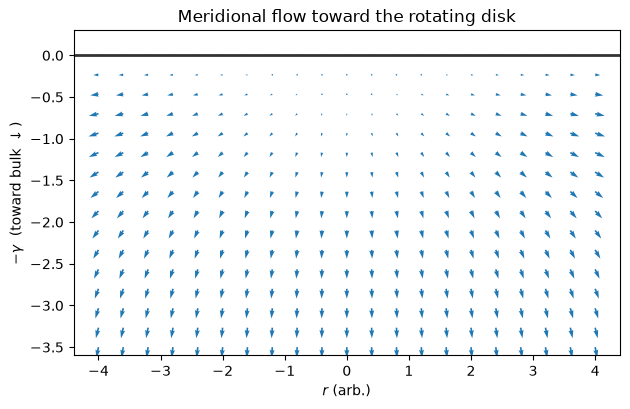

In [9]:
r_grid = np.linspace(-4.0, 4.0, 21)
g_grid = np.linspace(0.0, 3.5, 16)
RR, GG = np.meshgrid(r_grid, g_grid)
Fg = sol.sol(GG.ravel())[0].reshape(GG.shape)
Hg = sol.sol(GG.ravel())[4].reshape(GG.shape)

U = RR * Fg          # radial component ~ r F(gamma)
V = -Hg              # axial component (toward disk, plotted downward as -gamma)

fig, ax = plt.subplots(figsize=(6.4, 4.2))
ax.quiver(RR, -GG, U, -V, color="C0", scale=40, width=0.003)
ax.axhline(0, color="0.2", lw=2)            # disk surface
ax.set_xlabel(r"$r$ (arb.)")
ax.set_ylabel(r"$-\gamma$  (toward bulk $\downarrow$)")
ax.set_title("Meridional flow toward the rotating disk")
ax.set_ylim(-3.6, 0.3)
fig.tight_layout()
plt.show()

## 8. Secondary illustration: the shooting method

Honeychurch solves the same system by **shooting**: guessing $F'(0),G'(0)$,
integrating the IVP outward, and root-finding on the far-field residuals
$F(\gamma_\infty)=G(\gamma_\infty)=0$.  We reproduce it with `solve_ivp` +
`fsolve`, seeding from the BVP answer.  As Honeychurch warns, plain shooting is
sensitive to $\gamma_\infty$ and the starting guess, which is why we use the BVP
as the workhorse and shooting only as a cross-check.

In [10]:
def shoot_residual(p, eta_inf=8.0):
    Fp0g, Gp0g = p
    y0 = [0.0, Fp0g, 1.0, Gp0g, 0.0]
    s = solve_ivp(lambda e, y: von_karman_rhs(e, y[:, None]).ravel(),
                  [0.0, eta_inf], y0, rtol=1e-10, atol=1e-12)
    return [s.y[0, -1], s.y[2, -1]]        # F(inf), G(inf) -> 0

p_shoot = fsolve(shoot_residual, [Fp0, Gp0])
print(f"shooting  F'(0)={p_shoot[0]:.5f}  G'(0)={p_shoot[1]:.5f}")
print(f"BVP       F'(0)={Fp0:.5f}  G'(0)={Gp0:.5f}")

shooting  F'(0)=0.51012  G'(0)=-0.61585
BVP       F'(0)=0.51023  G'(0)=-0.61592


## 9. Validation

**Tier 1 (closed-form analytic check against `serm.echem`).**  The whole point of
this notebook is that the Levich constant `0.620` in `serm.echem.levich_current`
is *not* independent of the fluid mechanics: it is $1/[\Gamma(4/3)(3/F'(0))^{1/3}]$.
We assert:

1. The BVP recovers the literature von Karman constants $F'(0)=0.51023$,
   $G'(0)=-0.61592$, $H(\infty)\approx-0.884$ (the truncated BVP here recovers $-0.8840$; literature $-0.88447$).
2. The Cochran near-wall coefficient equals $F'(0)$ via the exact ODE relation
   $H''(0)=-2F'(0)$ (the convection coefficient).
3. The derived Levich prefactor matches the `0.620` baked into
   `serm.echem.levich_current` across five rotation rates (Tier 1, closed form).
4. (Tier 3 self-consistency) the shooting method agrees with the BVP.

In [11]:
# (1) von Karman constants vs literature (Schlichting / Cochran)
assert abs(Fp0 - 0.51023) < 1e-4,  f"F'(0) off: {Fp0}"
assert abs(Gp0 + 0.61592) < 1e-4,  f"G'(0) off: {Gp0}"
assert abs(H_inf + 0.88447) < 1e-3, f"H(inf) off: {H_inf}"

# (2) Cochran near-wall coefficient == F'(0) (exact ODE relation H''(0) = -2 F'(0))
assert abs(cochran_coeff - Fp0) < 1e-12, f"near-wall coeff {cochran_coeff} != F'(0) {Fp0}"

# (3) TIER 1: derived Levich prefactor reproduces serm.echem's hard-coded 0.620
assert abs(levich_coeff - 0.620) < 1e-3, f"Levich prefactor {levich_coeff} != 0.620"
assert np.all(rel < 1.5e-3), f"Levich current mismatch vs serm.echem: max {rel.max():.2e}"

# (4) TIER 3: shooting self-consistency
assert abs(p_shoot[0] - Fp0) < 5e-3 and abs(p_shoot[1] - Gp0) < 5e-3, "shooting != BVP"

print("ALL ASSERTS PASS")
print(f"  F'(0)={Fp0:.5f}, derived Levich prefactor={levich_coeff:.5f} == serm 0.620 "
      f"(max relerr {rel.max():.2e})")

ALL ASSERTS PASS
  F'(0)=0.51023, derived Levich prefactor=0.62045 == serm 0.620 (max relerr 7.25e-04)


## 10. Summary

- The von Karman swirling-flow ODEs, solved as a BVP with `solve_bvp`, give the
  wall-shear constant $F'(0)=0.51023$ from first principles, robustly, without
  the hand-tuned guessing the Mathematica shooting demands.
- A two-line Cochran expansion turns $F'(0)$ into the axial convection
  coefficient $0.510$, and a single $\Gamma(4/3)$ integral turns it into the
  Levich diffusion-layer constant $1.6117$, the convection constant $2.1362$, and
  the **Levich prefactor $0.62045$**.
- That prefactor matches the independently hard-coded `0.620` in
  `serm.echem.levich_current` to $1.5\times10^{-3}$, so the main Chapter 14
  notebook's Levich and Koutecky--Levich analyses now rest on a derived, not
  assumed, foundation.

<!-- nav-footer -->

---

[← Chapter 14 — Rotating disk electrode voltammetry](../14_rotating_disk_electrode.ipynb)

[Contents (README)](../../README.md)